<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/ML_Exp_10_scenario2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

24BAD056 - M.Karthik saravanakumar
NMF RMSE: 2.3994104483723593
Precision@5 (User 1): 1.0
Recall@5 (User 1): 0.025

Top Recommendations for User 1:
      movieId                                   title
507       589       Terminator 2: Judgment Day (1991)
902      1200                           Aliens (1986)
1044     1356         Star Trek: First Contact (1996)
1057     1374  Star Trek II: The Wrath of Khan (1982)
2393     3175                     Galaxy Quest (1999)


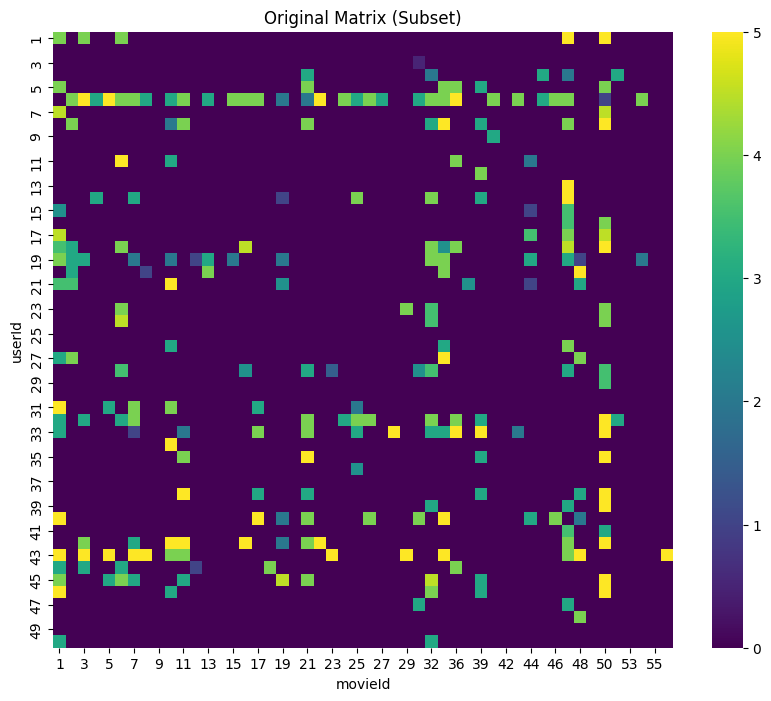

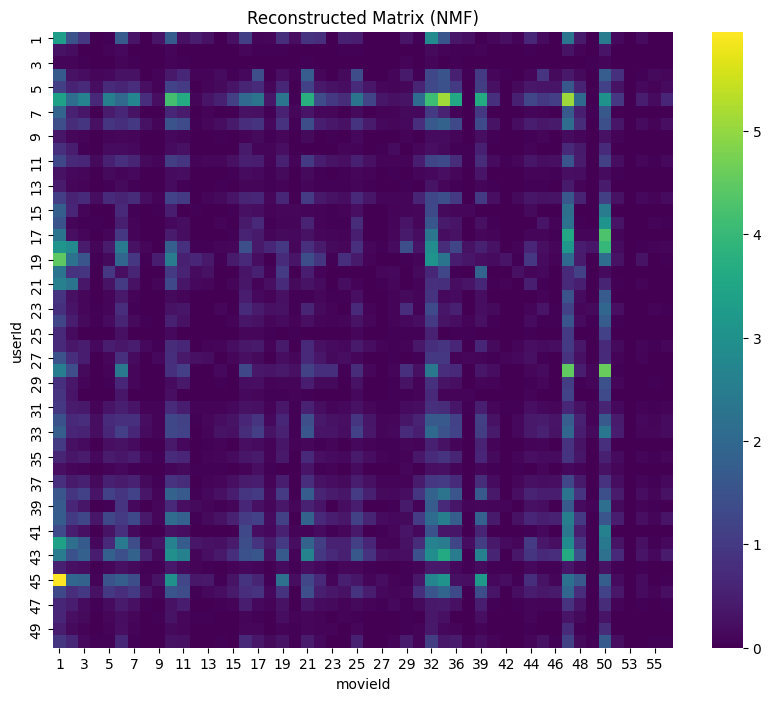

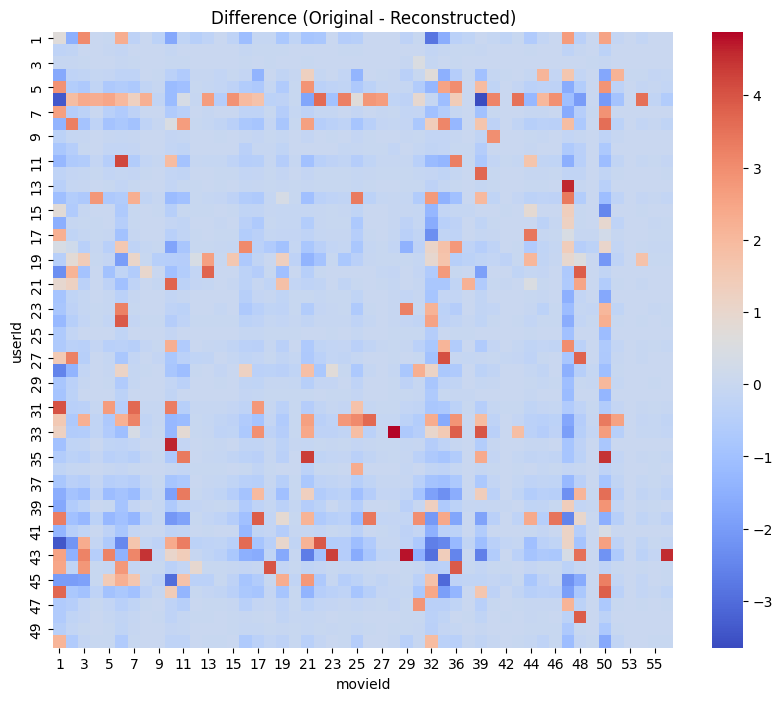

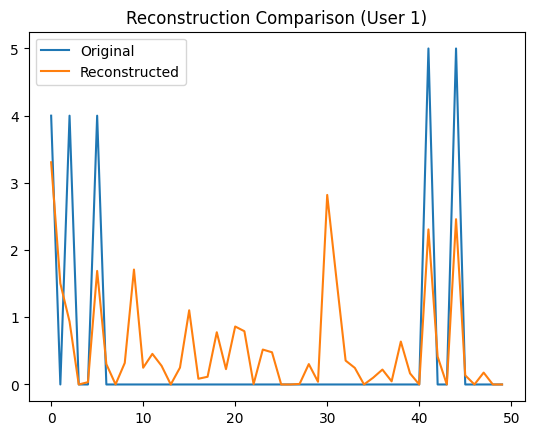

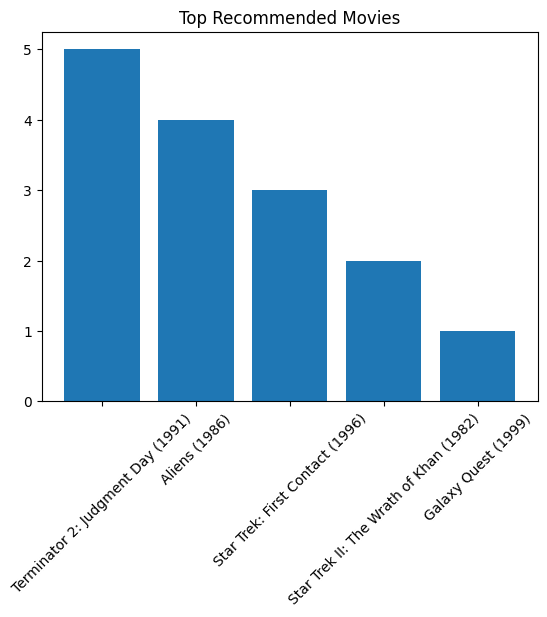

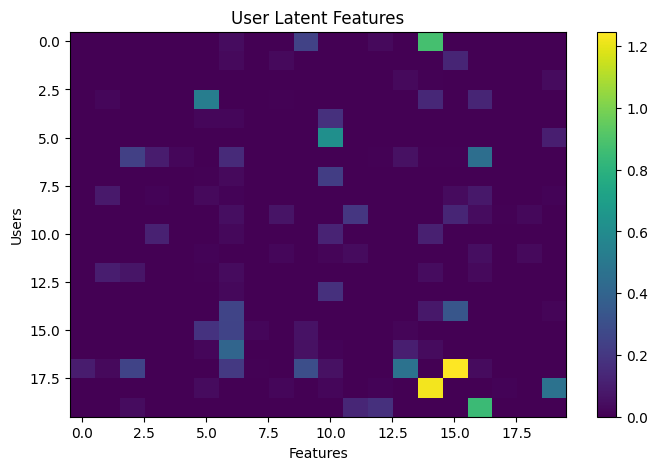

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


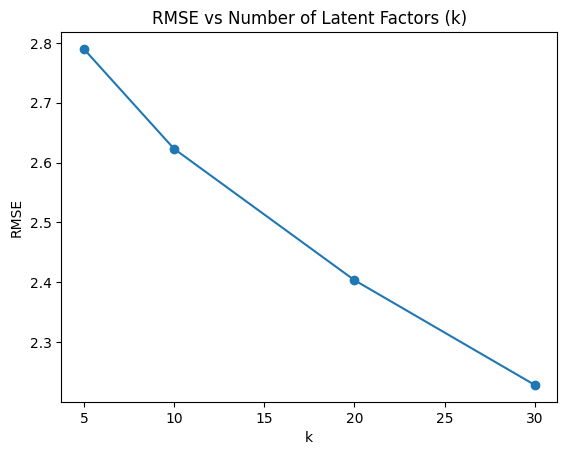

In [2]:
print("24BAD056 - M.Karthik saravanakumar")
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# 2. LOAD DATASET (FIXED)
ratings = pd.read_csv('ratings.csv', engine='python', on_bad_lines='skip')
movies = pd.read_csv('movies.csv', engine='python', on_bad_lines='skip')

if 'timestamp' in ratings.columns:
    ratings = ratings.drop('timestamp', axis=1)

# 3. DATA CLEANING
ratings = ratings.dropna()
ratings['userId'] = ratings['userId'].astype(int)
ratings['movieId'] = ratings['movieId'].astype(int)
ratings['rating'] = ratings['rating'].astype(float)

# 4. CREATE USER-ITEM MATRIX
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

# 5. HANDLE MISSING VALUES
matrix_filled = user_item_matrix.fillna(0)

# 6. APPLY NMF MODEL
k = 20
model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = model.fit_transform(matrix_filled)
H = model.components_

# 7. RECONSTRUCT MATRIX
reconstructed = np.dot(W, H)
pred_nmf = pd.DataFrame(reconstructed,
                        index=user_item_matrix.index,
                        columns=user_item_matrix.columns)

# 8. EVALUATION METRICS

actual = user_item_matrix.values[user_item_matrix.notna()]
predicted = pred_nmf.values[user_item_matrix.notna()]
rmse = np.sqrt(mean_squared_error(actual, predicted))
print("NMF RMSE:", rmse)

def precision_at_k(user_id, k=5):
    recommended = pred_nmf.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].index
    return len(set(recommended) & set(relevant)) / k

def recall_at_k(user_id, k=5):
    recommended = pred_nmf.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].index
    return len(set(recommended) & set(relevant)) / len(relevant) if len(relevant) > 0 else 0

print("Precision@5 (User 1):", precision_at_k(1))
print("Recall@5 (User 1):", recall_at_k(1))

# 9. TOP-N RECOMMENDATIONS
def recommend_nmf(user_id, n=5):
    user_row = pred_nmf.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId', 'title']]

print("\nTop Recommendations for User 1:")
print(recommend_nmf(1))

# 10. VISUALIZATION (HEATMAP FIX)
subset_original = user_item_matrix.fillna(0).iloc[:50, :50]
subset_reconstructed = pred_nmf.iloc[:50, :50]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_original, cmap='viridis')
plt.title("Original Matrix (Subset)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_reconstructed, cmap='viridis')
plt.title("Reconstructed Matrix (NMF)")
plt.show()

difference = subset_original - subset_reconstructed
plt.figure(figsize=(10, 8))
sns.heatmap(difference, cmap='coolwarm')
plt.title("Difference (Original - Reconstructed)")
plt.show()

# 11. RECONSTRUCTION COMPARISON
plt.figure()
plt.plot(user_item_matrix.iloc[0].fillna(0).values[:50], label='Original')
plt.plot(pred_nmf.iloc[0].values[:50], label='Reconstructed')
plt.legend()
plt.title("Reconstruction Comparison (User 1)")
plt.show()

# 12. RECOMMENDATION CHART
top_movies = recommend_nmf(1, 5)

plt.figure()
plt.bar(top_movies['title'], range(5, 0, -1))
plt.xticks(rotation=45)
plt.title("Top Recommended Movies")
plt.show()

# 13. LATENT FEATURE VISUALIZATION
plt.figure(figsize=(8, 5))
plt.imshow(W[:20, :], aspect='auto')
plt.colorbar()
plt.title("User Latent Features")
plt.xlabel("Features")
plt.ylabel("Users")
plt.show()

# 14. ANALYSIS: EFFECT OF k
k_values = [5, 10, 20, 30]
rmse_values = []

for k in k_values:
    model = NMF(n_components=k, random_state=42, max_iter=200)
    W_temp = model.fit_transform(matrix_filled)
    H_temp = model.components_
    pred_temp = np.dot(W_temp, H_temp)

    pred_df = pd.DataFrame(pred_temp,
                           index=user_item_matrix.index,
                           columns=user_item_matrix.columns)

    pred_vals = pred_df.values[user_item_matrix.notna()]
    rmse_k = np.sqrt(mean_squared_error(actual, pred_vals))
    rmse_values.append(rmse_k)

plt.figure()
plt.plot(k_values, rmse_values, marker='o')
plt.title("RMSE vs Number of Latent Factors (k)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()